# 🏥 Prediksi Kepuasan Pasien Menggunakan Model XGBoost
## Studi Kasus: Dataset Kepuasan Layanan Rumah Sakit

---

Notebook ini membangun dan membandingkan beberapa **pipeline preprocessing** yang berbeda-beda untuk memprediksi kepuasan pasien menggunakan algoritma **XGBoost (Extreme Gradient Boosting)**.

### 📌 Tujuan
- Mengeksplorasi data kepuasan pasien (Exploratory Data Analysis)
- Membandingkan **4 strategi preprocessing** yang berbeda:
  1. **Baseline** – Tanpa preprocessing khusus
  2. **Normalisasi (Min-Max Scaling)**
  3. **Standardisasi (Z-Score / StandardScaler)**
  4. **Robust Scaling + Penanganan Outlier**
- Melatih model XGBoost pada setiap pipeline dan membandingkan performanya

### 📂 Dataset
Dataset berisi **452 respons** survei kepuasan pasien dengan **17 fitur** yang mencakup aspek:
- Layanan administrasi (pendaftaran, antrian, prosedur)
- Kualitas medis (dokter, diagnosis, spesialis)
- Fasilitas (kebersihan, peralatan, ruang tunggu)
- Layanan pendukung (laboratorium, obat, parkir)

Semua nilai menggunakan **skala Likert 1–5**.

---
## 📦 1. Instalasi & Import Library

> ⚠️ **Jalankan cell instalasi terlebih dahulu** sebelum cell import.
> Setelah instalasi selesai, **restart kernel** lalu jalankan ulang dari cell ini.

In [1]:
# ── Bersihkan instalasi lama & install ulang bersih ─────────
import sys

print("🗑️  Menghapus scikit-learn lama...")
!{sys.executable} -m pip uninstall scikit-learn -y

print("🗑️  Menghapus scikit-learn-intelex jika ada (sering konflik)...")
!{sys.executable} -m pip uninstall scikit-learn-intelex -y

print("📦 Menginstall scikit-learn versi stabil terbaru...")
!{sys.executable} -m pip install --upgrade --force-reinstall scikit-learn

print("📦 Menginstall library lain...")
!{sys.executable} -m pip install --upgrade xgboost numpy pandas matplotlib seaborn -q

print()
print("✅ Selesai! WAJIB restart kernel sekarang:")
print("   Menu → Kernel → Restart Kernel")
print("   Setelah restart, jalankan ulang dari cell VERIFIKASI (bukan cell ini).")


🗑️  Menghapus scikit-learn lama...
Found existing installation: scikit-learn 1.7.2
Uninstalling scikit-learn-1.7.2:
  Successfully uninstalled scikit-learn-1.7.2
🗑️  Menghapus scikit-learn-intelex jika ada (sering konflik)...
📦 Menginstall scikit-learn versi stabil terbaru...


📦 Menginstall library lain...Collecting scikit-learn
  Using cached scikit_learn-1.7.2-cp310-cp310-win_amd64.whl.metadata (11 kB)
  Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl.metadata (60 kB)
  Using cached scipy-1.15.3-cp310-cp310-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.7.2-cp310-cp310-win_amd64.whl (8.9 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl (12.9 MB)
Using cached scipy-1.15.3-cp310-cp310-win_amd64.whl (41.3 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

  Attempting uninstall: threadpoolctl

    Found existing installation: threadpoolctl 3.6.0

    Uninstalling threadpoolctl-3.6.0:

   ---------------------------------------- 0/5 [threadpoolctl]
   ---------------------------------------- 0/5 [threadpoolctl]
   ---------------------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.1.1 requires numpy<2.0,>=1.16; python_version <= "3.11", but you have numpy 2.2.6 which is incompatible.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\User\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



✅ Selesai! WAJIB restart kernel sekarang:
   Menu → Kernel → Restart Kernel
   Setelah restart, jalankan ulang dari cell VERIFIKASI (bukan cell ini).



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\User\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
# ── Verifikasi versi library ──────────────────────────────────
import sklearn
import xgboost
import numpy, pandas, matplotlib, seaborn

print(f'scikit-learn : {sklearn.__version__}')
print(f'xgboost      : {xgboost.__version__}')
print(f'numpy        : {numpy.__version__}')
print(f'pandas       : {pandas.__version__}')
print(f'matplotlib   : {matplotlib.__version__}')
print(f'seaborn      : {seaborn.__version__}')

scikit-learn : 1.7.2
xgboost      : 3.2.0
numpy        : 1.26.4
pandas       : 2.3.3
matplotlib   : 3.10.8
seaborn      : 0.13.2


In [ ]:
# ── Core Libraries ──────────────────────────────────────────
import os
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Visualization ────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')

# ── Preprocessing ────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline

# ── Model ────────────────────────────────────────────────────
from xgboost import XGBClassifier

# ── Evaluation ───────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix
)

print('✅ Semua library berhasil diimport!')

✅ Semua library berhasil diimport!


---
## 📂 2. Load Dataset

In [12]:
import os
file_path = os.path.join("data", "datasetsatisdaction1", "datasetsatisfaction.csv")
df = pd.read_csv(file_path)

# Rename kolom untuk kemudahan penggunaan
df.columns = [
    'satisfaction', 'checkup_appointment', 'time_waiting',
    'admin_procedures', 'hygiene_cleaning', 'time_of_appointment',
    'quality_dr', 'specialists_available', 'communication_dr',
    'exact_diagnosis', 'modern_equipment', 'friendly_workers',
    'lab_services', 'availability_drugs', 'waiting_rooms',
    'hospital_rooms_quality', 'parking_amenities'
]

print(f'📊 Ukuran Dataset : {df.shape[0]} baris × {df.shape[1]} kolom')
df.head()

📊 Ukuran Dataset : 453 baris × 17 kolom


,satisfaction,checkup_appointment,time_waiting,admin_procedures,hygiene_cleaning,time_of_appointment,quality_dr,specialists_available,communication_dr,exact_diagnosis,modern_equipment,friendly_workers,lab_services,availability_drugs,waiting_rooms,hospital_rooms_quality,parking_amenities
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,2.0,2.0,1.0,2.0,1.0,2.0,2.0,1.0,2.0,1.0,2.0,1.0,1.0,1.0,1.0,2.0,1.0
2,2.0,1.0,1.0,2.0,2.0,2.0,4.0,4.0,4.0,4.0,1.0,4.0,4.0,1.0,2.0,2.0,2.0
3,2.0,2.0,4.0,1.0,1.0,2.0,4.0,1.0,1.0,4.0,1.0,1.0,4.0,5.0,4.0,1.0,1.0
4,3.0,4.0,1.0,1.0,2.0,1.0,5.0,5.0,5.0,5.0,2.0,5.0,5.0,5.0,1.0,1.0,1.0


---
## 🔍 3. Exploratory Data Analysis (EDA)

Sebelum membangun model, penting untuk memahami distribusi data, nilai hilang, dan hubungan antar fitur.

In [13]:
# ── Informasi dasar dataset
print('=== Info Dataset ===')
df.info()
print('\n=== Statistik Deskriptif ===')
df.describe()

=== Info Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 453 entries, 0 to 452
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   satisfaction            452 non-null    float64
 1   checkup_appointment     452 non-null    float64
 2   time_waiting            452 non-null    float64
 3   admin_procedures        452 non-null    float64
 4   hygiene_cleaning        452 non-null    float64
 5   time_of_appointment     452 non-null    float64
 6   quality_dr              452 non-null    float64
 7   specialists_available   452 non-null    float64
 8   communication_dr        452 non-null    float64
 9   exact_diagnosis         452 non-null    float64
 10  modern_equipment        452 non-null    float64
 11  friendly_workers        452 non-null    float64
 12  lab_services            452 non-null    float64
 13  availability_drugs      452 non-null    float64
 14  waiting_rooms        

,satisfaction,checkup_appointment,time_waiting,admin_procedures,hygiene_cleaning,time_of_appointment,quality_dr,specialists_available,communication_dr,exact_diagnosis,modern_equipment,friendly_workers,lab_services,availability_drugs,waiting_rooms,hospital_rooms_quality,parking_amenities
count,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000
mean,2.435841,2.626106,2.517699,2.595133,2.772124,2.575221,2.924779,2.674779,2.814159,2.829646,2.506637,2.829646,2.756637,2.745575,2.668142,2.714602,2.743363
std,0.526755,1.464897,1.407029,1.370346,1.264849,1.442499,1.522516,1.412011,1.443995,1.502314,1.300674,1.401522,1.470501,1.385498,1.242468,1.222646,1.157478
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,2.000000,2.000000,2.000000
50%,2.000000,3.000000,2.000000,2.000000,3.000000,2.000000,3.000000,2.500000,3.000000,3.000000,2.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
75%,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,4.000000,4.000000,3.250000,3.000000,3.000000
max,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [14]:
# ── Cek missing values
missing = df.isnull().sum()
print('=== Missing Values ===')
if missing.any():
    print(missing[missing > 0])
else:
    print('✅ Tidak ada missing values!')

=== Missing Values ===
satisfaction              1
checkup_appointment       1
time_waiting              1
admin_procedures          1
hygiene_cleaning          1
time_of_appointment       1
quality_dr                1
specialists_available     1
communication_dr          1
exact_diagnosis           1
modern_equipment          1
friendly_workers          1
lab_services              1
availability_drugs        1
waiting_rooms             1
hospital_rooms_quality    1
parking_amenities         1
dtype: int64


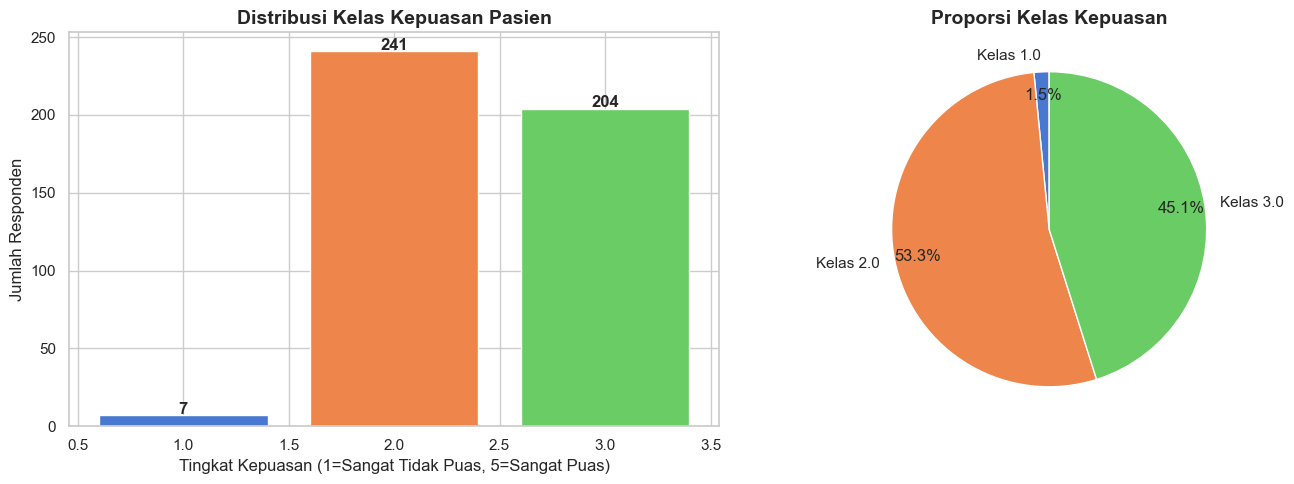

In [15]:
# ── Distribusi label target: satisfaction
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

value_counts = df['satisfaction'].value_counts().sort_index()
axes[0].bar(value_counts.index, value_counts.values,
            color=sns.color_palette('muted'), edgecolor='white')
axes[0].set_title('Distribusi Kelas Kepuasan Pasien', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tingkat Kepuasan (1=Sangat Tidak Puas, 5=Sangat Puas)')
axes[0].set_ylabel('Jumlah Responden')
for i, v in zip(value_counts.index, value_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

axes[1].pie(value_counts.values, labels=[f'Kelas {k}' for k in value_counts.index],
            autopct='%1.1f%%', colors=sns.color_palette('muted'),
            startangle=90, pctdistance=0.85)
axes[1].set_title('Proporsi Kelas Kepuasan', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

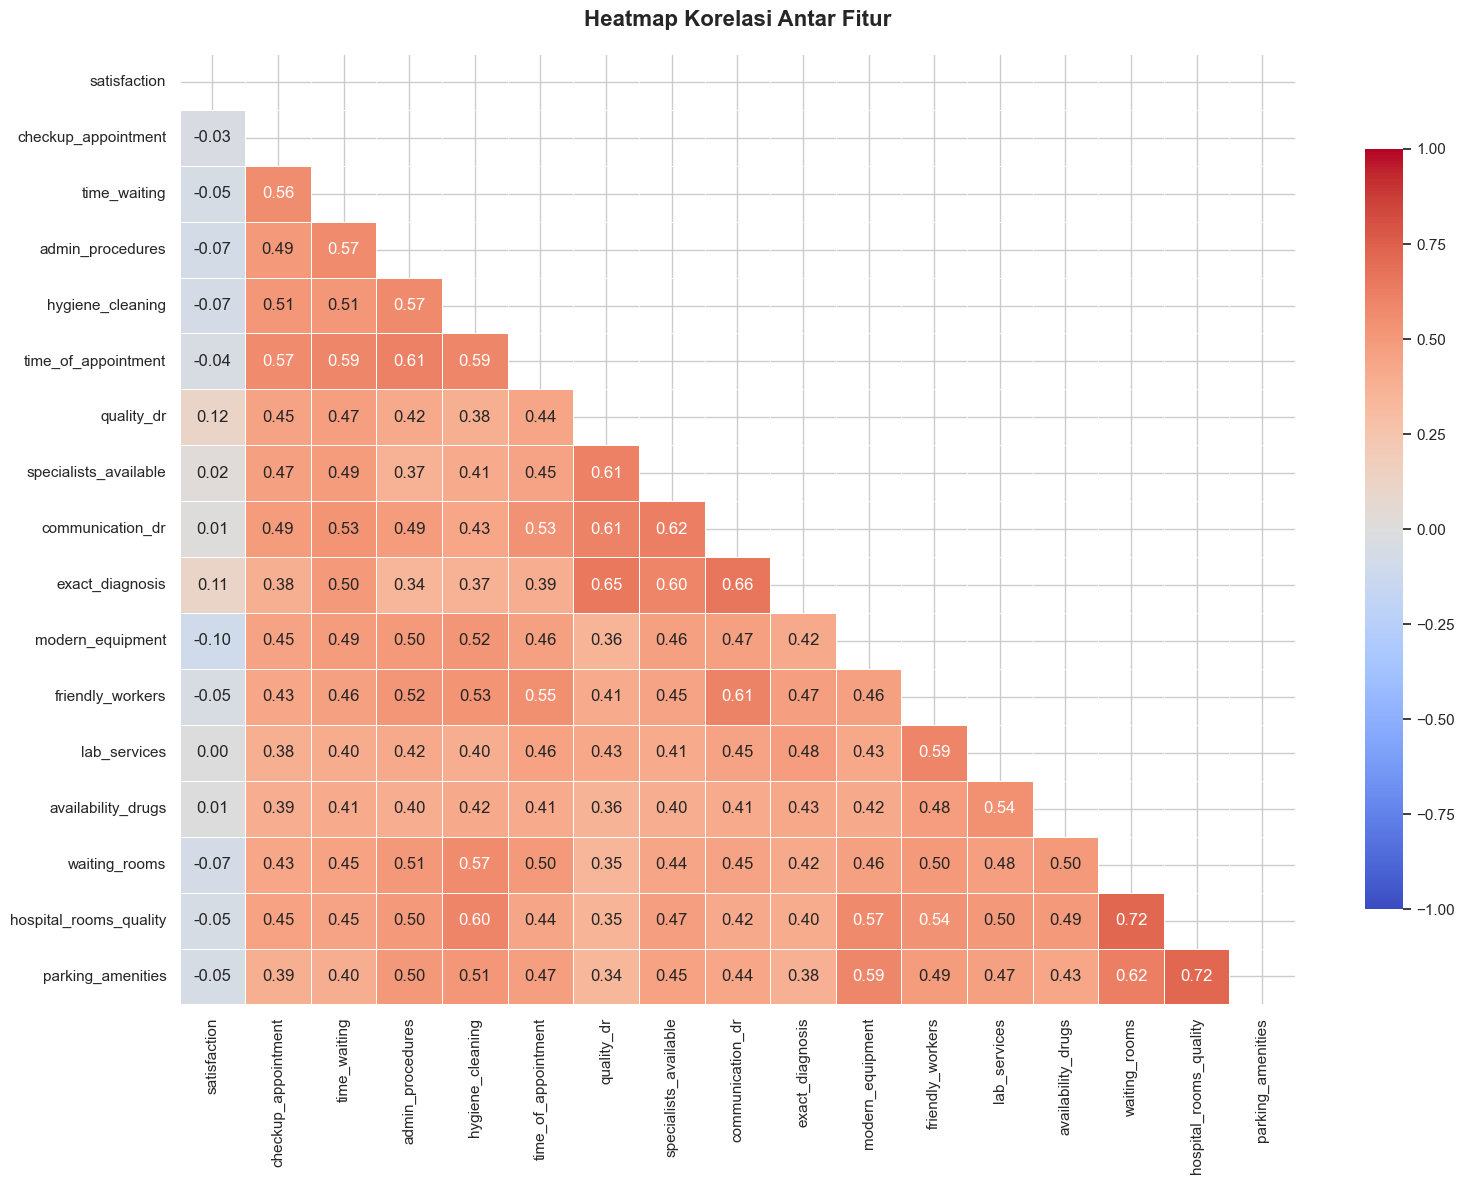

In [16]:
# ── Heatmap korelasi antar fitur
fig, ax = plt.subplots(figsize=(16, 12))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Heatmap Korelasi Antar Fitur', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

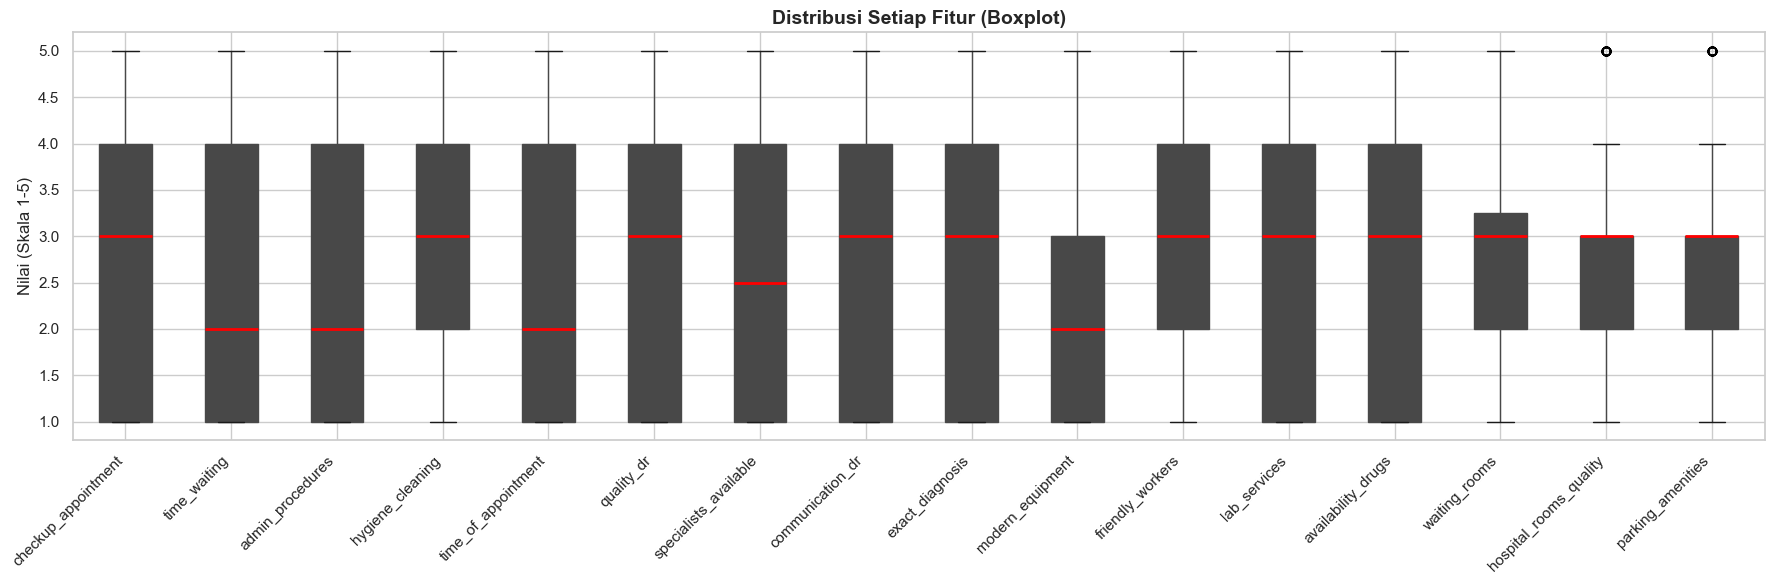

In [17]:
# ── Boxplot distribusi semua fitur
feature_cols = [c for c in df.columns if c != 'satisfaction']
fig, ax = plt.subplots(figsize=(18, 6))
df[feature_cols].boxplot(ax=ax, vert=True, patch_artist=True,
                          medianprops=dict(color='red', linewidth=2))
ax.set_xticklabels(feature_cols, rotation=45, ha='right')
ax.set_title('Distribusi Setiap Fitur (Boxplot)', fontsize=14, fontweight='bold')
ax.set_ylabel('Nilai (Skala 1-5)')
plt.tight_layout()
plt.show()

---
## ✂️ 4. Persiapan Data: Pemisahan Fitur & Target

Kolom `satisfaction` merupakan **variabel target (Y)**, sedangkan 16 kolom lainnya adalah **fitur input (X)**.

Karena XGBoost menggunakan indeks kelas mulai dari **0**, kita perlu menggeser nilai target (1–5) menjadi (0–4).

In [22]:
# ── Cek dan hapus missing values
print('Sebelum cleaning:')
print(f'Total baris : {len(df)}')
print(f'NaN di satisfaction: {df["satisfaction"].isna().sum()}')

# Hapus baris dengan nilai NaN
df = df.dropna()

print(f'\nSetelah cleaning:')
print(f'Total baris : {len(df)}')

# Persiapan fitur dan target
X = df.drop(columns=['satisfaction']).values
y = df['satisfaction'].values - 1   # Shift: 1-5 → 0-4 (XGBoost requirement)

feature_names = [c for c in df.columns if c != 'satisfaction']
n_classes = len(np.unique(y))

print(f'\nJumlah Fitur  : {X.shape[1]}')
print(f'Jumlah Sampel : {X.shape[0]}')
print(f'Jumlah Kelas  : {n_classes} → {np.unique(y)}')

Sebelum cleaning:
Total baris : 453
NaN di satisfaction: 1

Setelah cleaning:
Total baris : 452

Jumlah Fitur  : 16
Jumlah Sampel : 452
Jumlah Kelas  : 3 → [0. 1. 2.]


In [23]:
# ── Train-Test Split (80:20) dengan Stratified Sampling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set  : {X_train.shape[0]} sampel ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Testing set   : {X_test.shape[0]} sampel  ({X_test.shape[0]/len(X)*100:.1f}%)')
print(f'\nDistribusi kelas Train : {dict(zip(*np.unique(y_train, return_counts=True)))}')
print(f'Distribusi kelas Test  : {dict(zip(*np.unique(y_test, return_counts=True)))}')

Training set  : 361 sampel (79.9%)
Testing set   : 91 sampel  (20.1%)

Distribusi kelas Train : {0.0: 6, 1.0: 192, 2.0: 163}
Distribusi kelas Test  : {0.0: 1, 1.0: 49, 2.0: 41}


---
## ⚙️ 5. Pipeline Preprocessing

Kita akan membandingkan **4 pipeline preprocessing** yang berbeda:

| # | Nama Pipeline | Metode | Keterangan |
|---|--------------|--------|------------|
| 1 | **Baseline** | Tanpa scaling | Data asli, tidak dinormalisasi |
| 2 | **MinMax Scaling** | `MinMaxScaler` | Skala fitur ke rentang [0, 1] |
| 3 | **Standard Scaling** | `StandardScaler` | Mean=0, Std=1 (Z-score normalization) |
| 4 | **Robust Scaling** | `RobustScaler` | Tahan terhadap outlier (gunakan median & IQR) |

Setiap pipeline digabungkan dengan **XGBClassifier** menggunakan `sklearn.pipeline.Pipeline`.

In [24]:
# ── Konfigurasi XGBoost (sama untuk semua pipeline)
xgb_params = dict(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

# ── Definisi 4 Pipeline
pipelines = {
    'Baseline (No Scaling)': Pipeline([
        ('clf', XGBClassifier(**xgb_params))
    ]),
    'MinMax Scaling': Pipeline([
        ('scaler', MinMaxScaler()),
        ('clf', XGBClassifier(**xgb_params))
    ]),
    'Standard Scaling (Z-score)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', XGBClassifier(**xgb_params))
    ]),
    'Robust Scaling': Pipeline([
        ('scaler', RobustScaler()),
        ('clf', XGBClassifier(**xgb_params))
    ])
}

print('✅ 4 Pipeline berhasil dibuat:')
for name in pipelines:
    print(f'  - {name}')

✅ 4 Pipeline berhasil dibuat:
  - Baseline (No Scaling)
  - MinMax Scaling
  - Standard Scaling (Z-score)
  - Robust Scaling


---
## 🏋️ 6. Pelatihan Model & Evaluasi

Setiap pipeline dilatih pada `X_train` dan dievaluasi pada `X_test`.
Selain itu, kita gunakan **5-Fold Stratified Cross-Validation** untuk mengukur stabilitas model.

In [25]:
results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, pipe in pipelines.items():
    print(f'\n🔄 Training: {name} ...')

    # ── Latih model
    pipe.fit(X_train, y_train)

    # ── Prediksi
    y_pred = pipe.predict(X_test)

    # ── Akurasi train & test
    train_acc = accuracy_score(y_train, pipe.predict(X_train))
    test_acc  = accuracy_score(y_test, y_pred)

    # ── Cross-validation
    cv_scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy')

    results[name] = {
        'pipeline'  : pipe,
        'y_pred'    : y_pred,
        'train_acc' : train_acc,
        'test_acc'  : test_acc,
        'cv_mean'   : cv_scores.mean(),
        'cv_std'    : cv_scores.std(),
        'cv_scores' : cv_scores
    }

    print(f'   Train Acc : {train_acc:.4f}')
    print(f'   Test Acc  : {test_acc:.4f}')
    print(f'   CV Acc    : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

print('\n✅ Semua pipeline selesai dilatih!')


🔄 Training: Baseline (No Scaling) ...
   Train Acc : 0.9612
   Test Acc  : 0.6264
   CV Acc    : 0.5509 ± 0.0182

🔄 Training: MinMax Scaling ...
   Train Acc : 0.9612
   Test Acc  : 0.6264
   CV Acc    : 0.5509 ± 0.0182

🔄 Training: Standard Scaling (Z-score) ...
   Train Acc : 0.9612
   Test Acc  : 0.6264
   CV Acc    : 0.5509 ± 0.0182

🔄 Training: Robust Scaling ...
   Train Acc : 0.9612
   Test Acc  : 0.6264
   CV Acc    : 0.5509 ± 0.0182

✅ Semua pipeline selesai dilatih!


---
## 📊 7. Perbandingan Performa Semua Pipeline

In [26]:
# ── Tabel ringkasan performa
summary = pd.DataFrame({
    'Pipeline'    : list(results.keys()),
    'Train Acc'   : [v['train_acc'] for v in results.values()],
    'Test Acc'    : [v['test_acc']  for v in results.values()],
    'CV Mean'     : [v['cv_mean']   for v in results.values()],
    'CV Std'      : [v['cv_std']    for v in results.values()]
})
summary = summary.sort_values('Test Acc', ascending=False).reset_index(drop=True)

styled = summary.style\
    .background_gradient(subset=['Test Acc', 'CV Mean'], cmap='RdYlGn')\
    .format({'Train Acc': '{:.4f}', 'Test Acc': '{:.4f}',
             'CV Mean': '{:.4f}', 'CV Std': '{:.4f}'})\
    .set_caption('📋 Ringkasan Performa Model XGBoost')

print('=== RINGKASAN PERFORMA ===')
display(styled)

=== RINGKASAN PERFORMA ===


,Pipeline,Train Acc,Test Acc,CV Mean,CV Std
0,Baseline (No Scaling),0.9612,0.6264,0.5509,0.0182
1,MinMax Scaling,0.9612,0.6264,0.5509,0.0182
2,Standard Scaling (Z-score),0.9612,0.6264,0.5509,0.0182
3,Robust Scaling,0.9612,0.6264,0.5509,0.0182


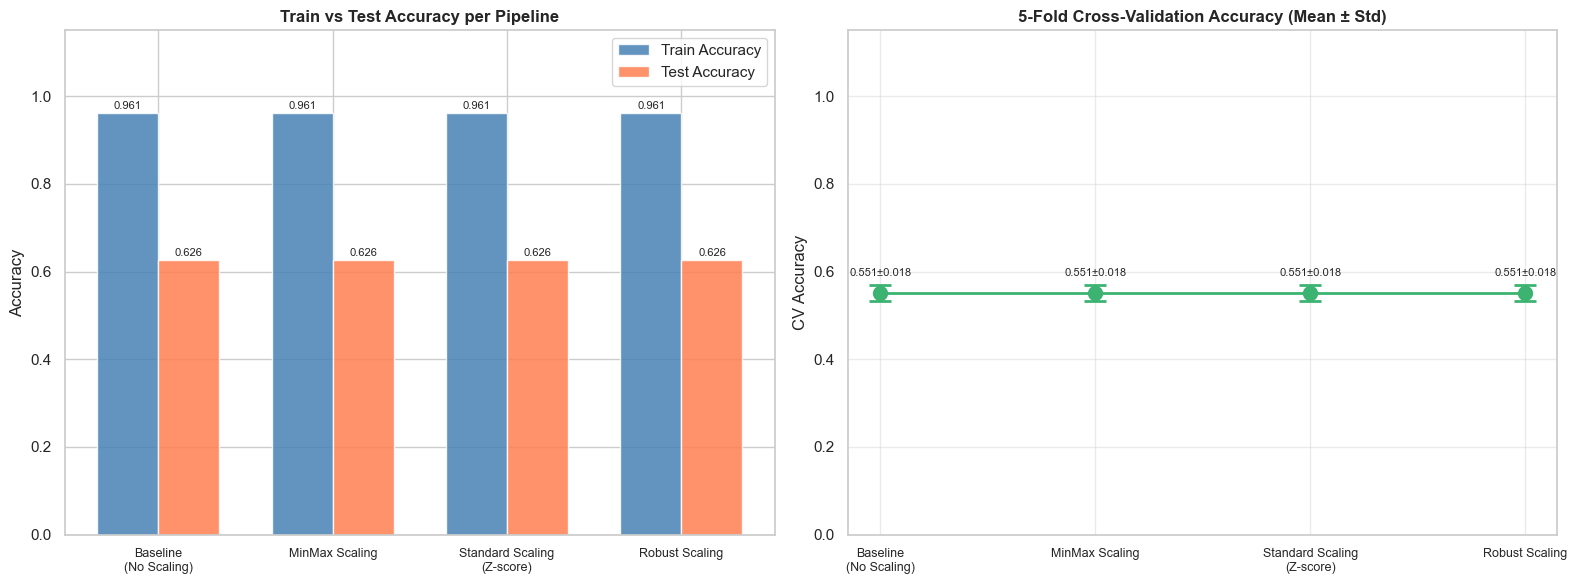

In [27]:
# ── Visualisasi perbandingan performa
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
names = [n.replace(' (', '\n(') for n in list(results.keys())]

# Bar chart: Train vs Test Accuracy
x = np.arange(len(results))
w = 0.35
train_accs = [v['train_acc'] for v in results.values()]
test_accs  = [v['test_acc']  for v in results.values()]

bars1 = axes[0].bar(x - w/2, train_accs, w, label='Train Accuracy', color='steelblue', alpha=0.85, edgecolor='white')
bars2 = axes[0].bar(x + w/2, test_accs,  w, label='Test Accuracy',  color='coral',     alpha=0.85, edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, fontsize=9)
axes[0].set_ylim(0, 1.15)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Train vs Test Accuracy per Pipeline', fontweight='bold')
axes[0].legend()
for bar in bars1:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{bar.get_height():.3f}', ha='center', fontsize=8)
for bar in bars2:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{bar.get_height():.3f}', ha='center', fontsize=8)

# Line chart: CV scores
cv_means = [v['cv_mean'] for v in results.values()]
cv_stds  = [v['cv_std']  for v in results.values()]
axes[1].errorbar(range(len(results)), cv_means, yerr=cv_stds,
                 fmt='o-', capsize=8, capthick=2, linewidth=2,
                 markersize=10, color='mediumseagreen')
axes[1].set_xticks(range(len(results)))
axes[1].set_xticklabels(names, fontsize=9)
axes[1].set_ylim(0, 1.15)
axes[1].set_ylabel('CV Accuracy')
axes[1].set_title('5-Fold Cross-Validation Accuracy (Mean ± Std)', fontweight='bold')
axes[1].grid(True, alpha=0.4)
for i, (m, s) in enumerate(zip(cv_means, cv_stds)):
    axes[1].annotate(f'{m:.3f}±{s:.3f}', (i, m+s+0.02), ha='center', fontsize=8)

plt.tight_layout()
plt.show()

---
## 🧩 8. Analisis Detail per Pipeline

### 8a. Confusion Matrix – Semua Pipeline

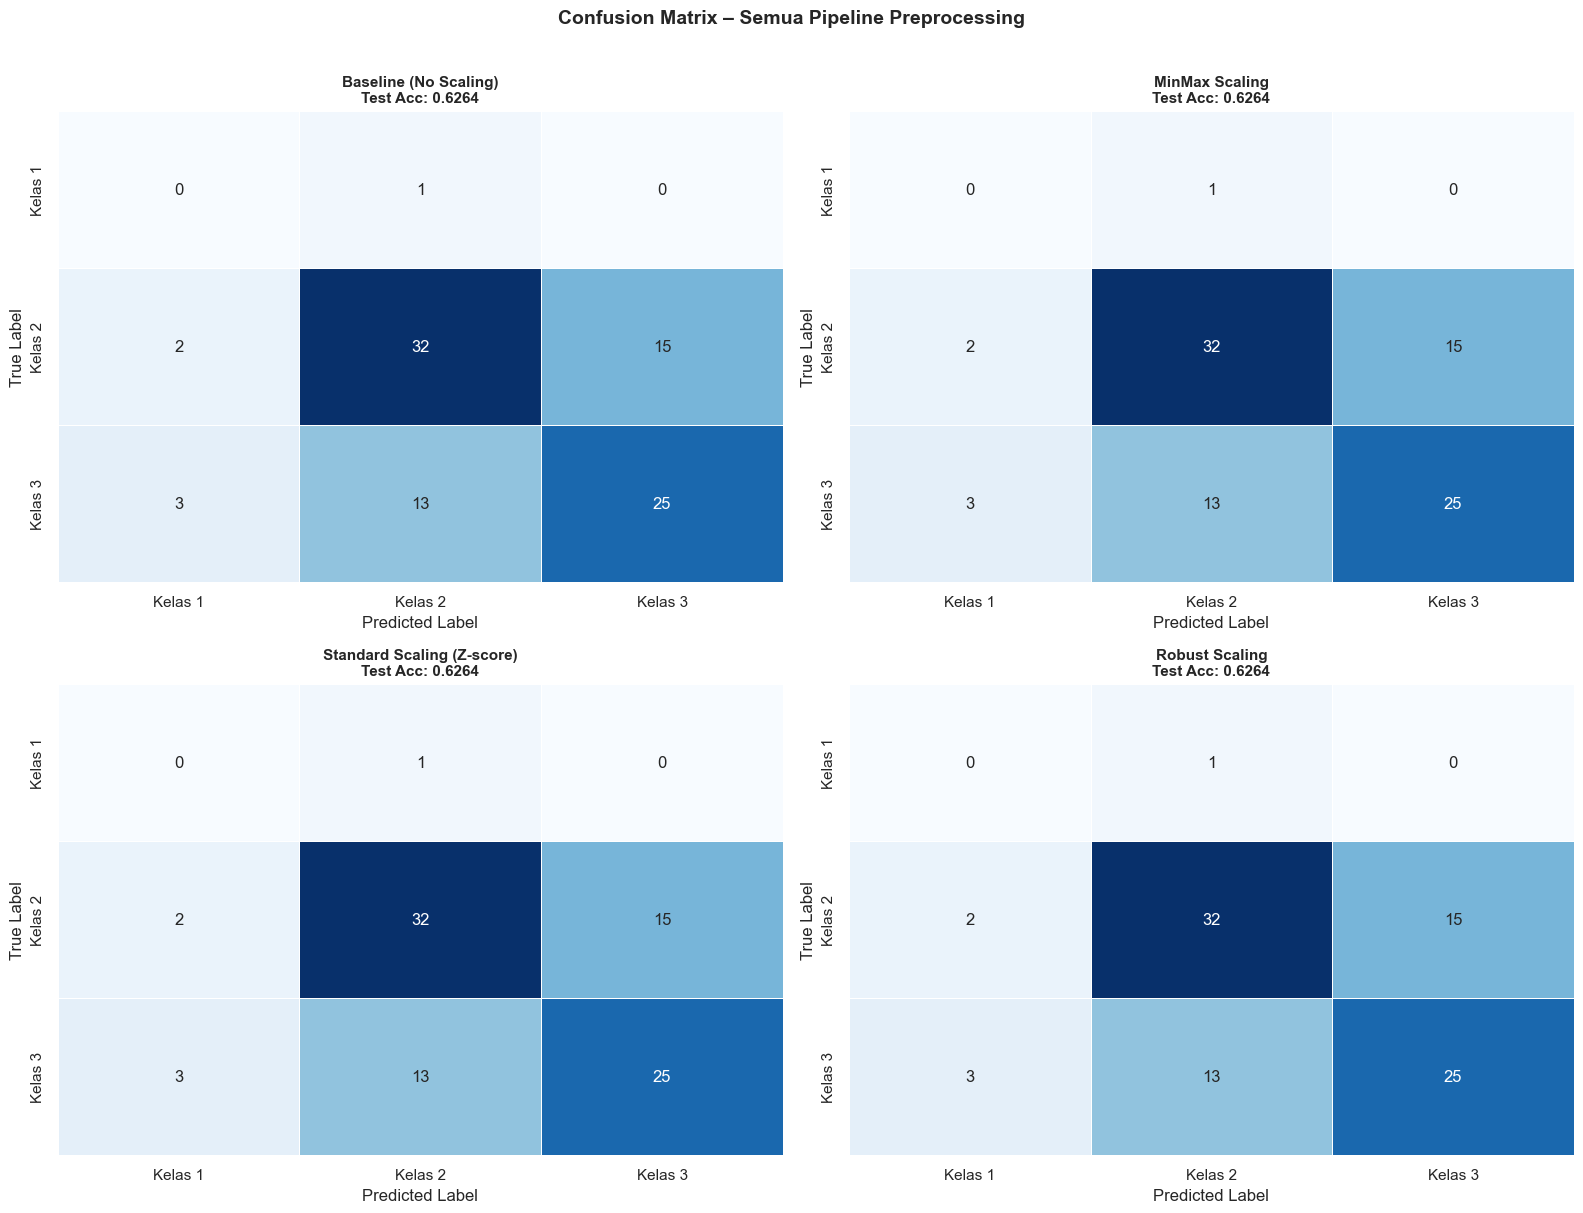

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
class_labels = [f'Kelas {i+1}' for i in range(n_classes)]

for idx, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels,
                ax=axes[idx], cbar=False, linewidths=0.5)
    axes[idx].set_title(f'{name}\nTest Acc: {res["test_acc"]:.4f}',
                        fontweight='bold', fontsize=11)
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_ylabel('True Label')

plt.suptitle('Confusion Matrix – Semua Pipeline Preprocessing', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 8b. Classification Report – Pipeline Terbaik

In [29]:
# ── Identifikasi pipeline terbaik berdasarkan Test Accuracy
best_name = max(results, key=lambda k: results[k]['test_acc'])
best_res  = results[best_name]

print(f'🏆 Pipeline Terbaik : {best_name}')
print(f'   Test Accuracy   : {best_res["test_acc"]:.4f}')
print(f'   CV Mean Acc     : {best_res["cv_mean"]:.4f} ± {best_res["cv_std"]:.4f}')
print()
print('=== CLASSIFICATION REPORT ===')
print(classification_report(y_test, best_res['y_pred'], target_names=class_labels))

🏆 Pipeline Terbaik : Baseline (No Scaling)
   Test Accuracy   : 0.6264
   CV Mean Acc     : 0.5509 ± 0.0182

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     Kelas 1       0.00      0.00      0.00         1
     Kelas 2       0.70      0.65      0.67        49
     Kelas 3       0.62      0.61      0.62        41

    accuracy                           0.63        91
   macro avg       0.44      0.42      0.43        91
weighted avg       0.66      0.63      0.64        91



---
## 🌲 9. Feature Importance – Pipeline Terbaik

XGBoost menyediakan skor **feature importance** yang menunjukkan seberapa besar kontribusi setiap fitur dalam proses pembuatan keputusan model.

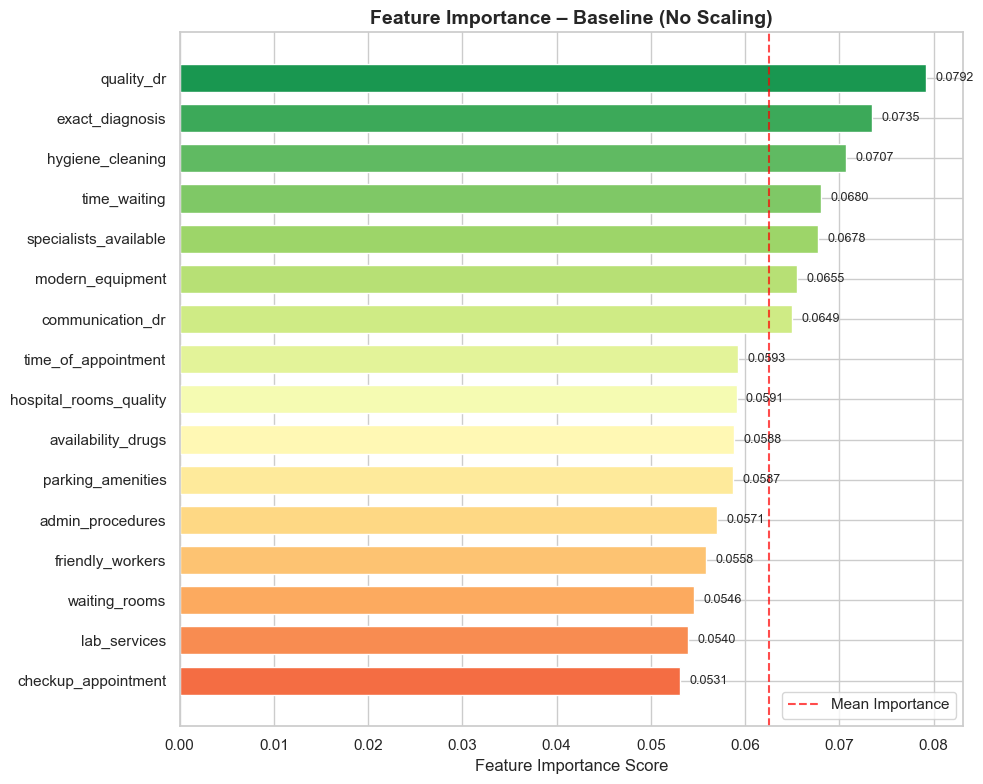


Top 5 Fitur Paling Penting:
              Feature  Importance
           quality_dr    0.079184
      exact_diagnosis    0.073499
     hygiene_cleaning    0.070707
         time_waiting    0.068022
specialists_available    0.067762


In [30]:
best_clf = best_res['pipeline'].named_steps['clf']
importances = best_clf.feature_importances_

feat_df = pd.DataFrame({
    'Feature'    : feature_names,
    'Importance' : importances
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors_fi = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(feat_df)))
bars = ax.barh(feat_df['Feature'], feat_df['Importance'],
               color=colors_fi, edgecolor='white', height=0.7)
ax.set_xlabel('Feature Importance Score', fontsize=12)
ax.set_title(f'Feature Importance – {best_name}', fontsize=14, fontweight='bold')
ax.axvline(importances.mean(), color='red', linestyle='--', alpha=0.7, label='Mean Importance')
ax.legend()
for bar in bars:
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print('\nTop 5 Fitur Paling Penting:')
top5 = feat_df.sort_values('Importance', ascending=False).head(5)
print(top5.to_string(index=False))

---
## 📈 10. Analisis Cross-Validation per Fold

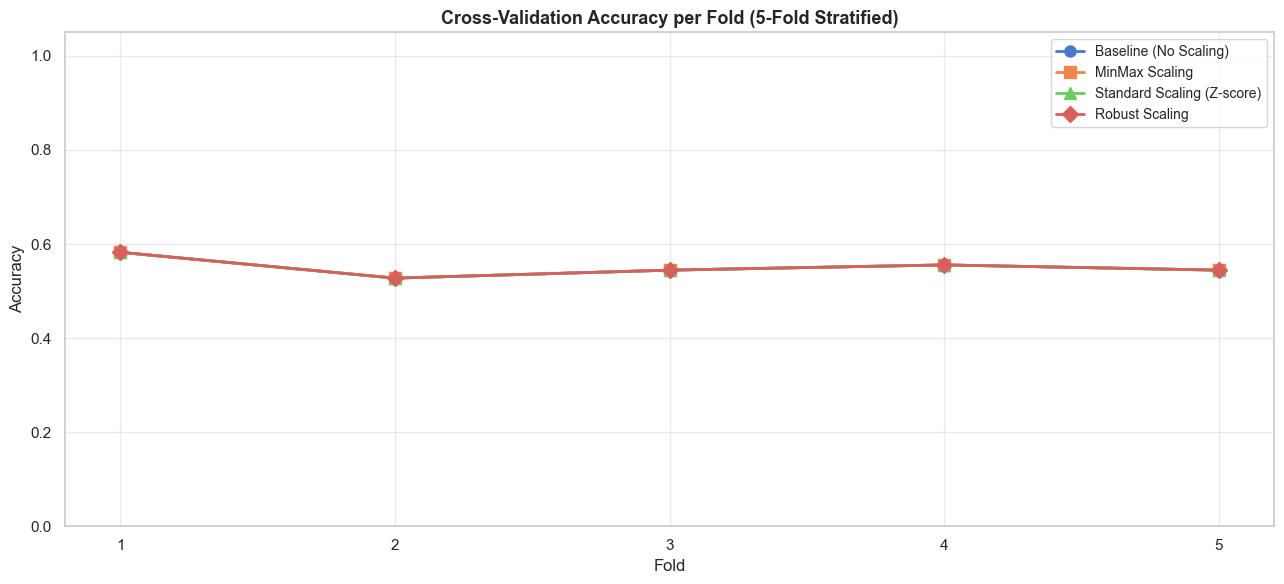

In [31]:
fig, ax = plt.subplots(figsize=(13, 6))
colors_cv = sns.color_palette('muted', len(results))
markers = ['o', 's', '^', 'D']

for idx, (name, res) in enumerate(results.items()):
    folds = np.arange(1, 6)
    ax.plot(folds, res['cv_scores'], marker=markers[idx],
            label=name, color=colors_cv[idx], linewidth=2, markersize=8)

ax.set_xticks(range(1, 6))
ax.set_xlabel('Fold', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Cross-Validation Accuracy per Fold (5-Fold Stratified)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.4)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

---
## 📋 11. Ringkasan & Kesimpulan

### Hasil Perbandingan Pipeline

Empat pipeline preprocessing dievaluasi menggunakan model XGBoost pada dataset kepuasan pasien:

| Metode | Deskripsi | Cocok Untuk |
|--------|-----------|-------------|
| **Baseline** | Data asli tanpa transformasi | Fitur sudah dalam skala serupa (seperti data ini 1–5) |
| **MinMax Scaling** | Rentangkan fitur ke [0, 1] | Saat algoritma sensitif terhadap skala, tidak ada outlier |
| **Standard Scaling** | Normalisasi ke mean=0, std=1 | Data mengikuti distribusi Gaussian |
| **Robust Scaling** | Gunakan median & IQR | Data memiliki banyak outlier |

### 📝 Catatan Penting

- **XGBoost pada dasarnya tidak sensitif terhadap scaling** karena berbasis pohon keputusan (decision tree), sehingga perbedaan antar pipeline umumnya kecil.
- Namun, preprocessing yang tepat tetap penting untuk **generalisasi** dan **stabilitas training**.
- Pipeline dengan **Robust Scaling** direkomendasikan jika ada indikasi outlier dalam data survei.

In [32]:
print('=' * 62)
print('          RINGKASAN AKHIR SELURUH PIPELINE')
print('=' * 62)
print(f'{"Pipeline":<35} {"Test Acc":>10} {"CV Mean":>10} {"CV Std":>6}')
print('-' * 62)
for name, res in sorted(results.items(), key=lambda x: x[1]['test_acc'], reverse=True):
    marker = ' ← TERBAIK' if name == best_name else ''
    print(f'{name:<35} {res["test_acc"]:>10.4f} {res["cv_mean"]:>10.4f} {res["cv_std"]:>6.4f}{marker}')
print('=' * 62)
print(f'\n🏆 Pipeline Terbaik : {best_name}')
print(f'   Test Accuracy    : {results[best_name]["test_acc"]:.4f}')

          RINGKASAN AKHIR SELURUH PIPELINE
Pipeline                              Test Acc    CV Mean CV Std
--------------------------------------------------------------
Baseline (No Scaling)                   0.6264     0.5509 0.0182 ← TERBAIK
MinMax Scaling                          0.6264     0.5509 0.0182
Standard Scaling (Z-score)              0.6264     0.5509 0.0182
Robust Scaling                          0.6264     0.5509 0.0182

🏆 Pipeline Terbaik : Baseline (No Scaling)
   Test Accuracy    : 0.6264
